# **Preparing Dependancies**

In [1]:
!pip install -q diffusers transformers accelerate safetensors

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc

from PIL import Image, ImageDraw, ImageFilter, ImageOps, ImageChops

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionInpaintPipeline
)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import modul-modul penting dari Diffusers
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionInpaintPipeline
)

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    use_safetensors=True,
    safety_checker=None
).to(device)

pipe.enable_attention_slicing()

print("Text-to-Image model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Text-to-Image model loaded!


## **Generate Image**

In [5]:
prompt = "an astronaut standing on the moon surface, earth in background moonscape, craters, stars, illustration, 2d art, simple, clean lines, space"
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
seed = 222

  0%|          | 0/50 [00:00<?, ?it/s]

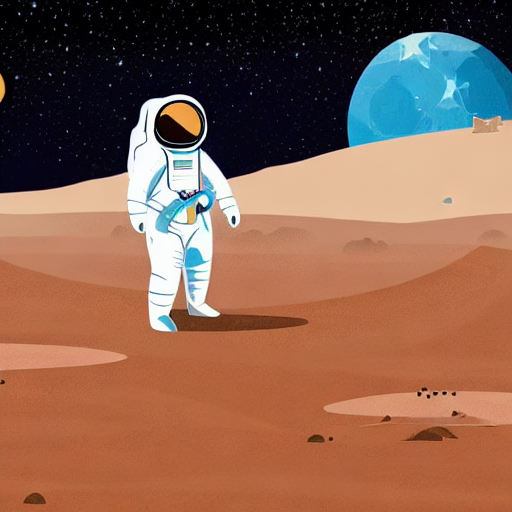

In [6]:

def generate_simple_image(prompt, negative_prompt, seed):

    generator = torch.Generator("cuda").manual_seed(seed)

    image_basic = pipe(prompt=prompt,
                 negative_prompt=negative_prompt,
                 generator=generator
                 ).images[0]

    return image_basic

simple_image = generate_simple_image(prompt, negative_prompt, seed)
simple_image

## **Generate Image with Hyperparameter Configuration**

In [7]:
scales = 15
steps = 30

  0%|          | 0/30 [00:00<?, ?it/s]

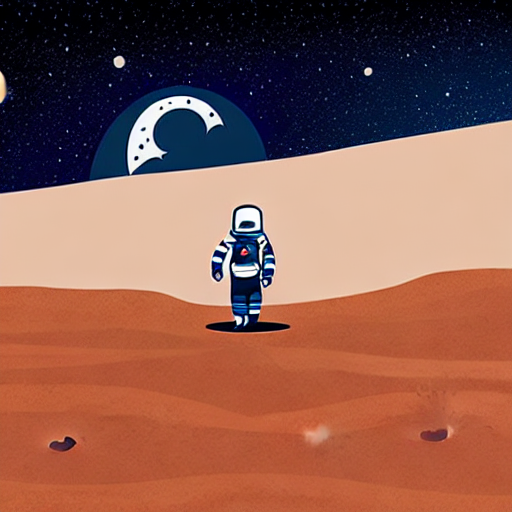

In [8]:
# Fungsi Advanced
def generate_advanced_image(prompt, negative_prompt, seed, guidance_scale, num_inference_steps):

    # Setup Generator (Seed)
    generator = torch.Generator("cuda").manual_seed(seed)

    # Generate gambar standard
    image_advanced = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator
        ).images[0]

    return image_advanced


image_advanced = generate_advanced_image(prompt, negative_prompt, seed, scales, steps)
image_advanced

## **Guidance Scale Comparison**

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

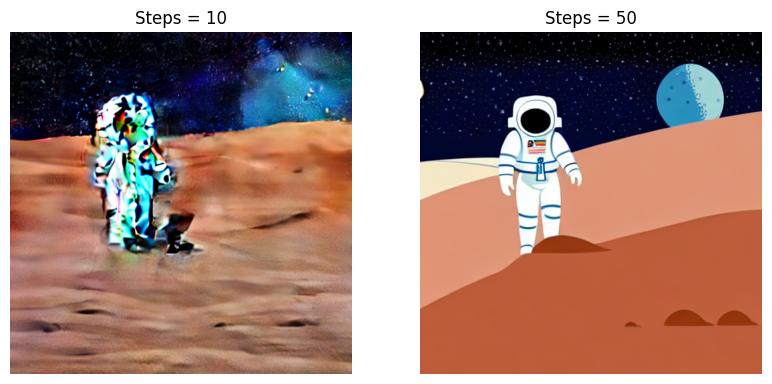

In [9]:
steps_list = [10, 50]
images = []

for steps in steps_list:
    generator = torch.Generator("cuda").manual_seed(seed)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=scales,
        generator=generator
    ).images[0]
    images.append(img)

plt.figure(figsize=(15, 5))
for i, img in enumerate(images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Steps = {steps_list[i]}")
    plt.axis("off")
plt.show()

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah (10):**  
    Gambar dengan inference steps rendah dihasilkan lebih cepat tetapi mungkin memiliki noise, artefak, atau detail yang kurang halus. Robot mungkin terlihat kurang detail dan background mungkin kurang halus. Terkadang terlihat seperti "belum selesai" atau kurang refined.

*   **Gambar dengan "Step" Tinggi (50):**  
    Gambar dengan inference steps tinggi memiliki detail yang lebih halus, stabil, dan berkualitas lebih baik. Robot dan background terlihat lebih jelas dan rapi. Prosesnya lebih lambat tetapi hasilnya lebih optimal dan tidak ada noise yang signifikan.

## **Inference Steps Comparison**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

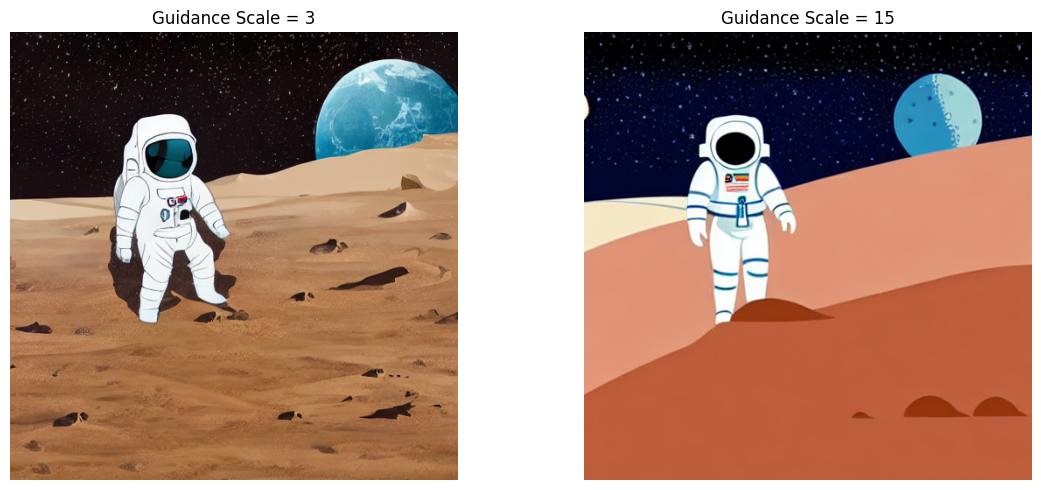

In [10]:
guidance_scales = [3, 15]
images = []

for scale in guidance_scales:
    generator = torch.Generator(device).manual_seed(seed)

    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=scale,
        num_inference_steps=steps,
        generator=generator
    ).images[0]

    images.append(img)

plt.figure(figsize=(12, 5))

for i, img in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.title(f"Guidance Scale = {guidance_scales[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah (3.0):**   
    Gambar dengan guidance scale rendah memiliki lebih banyak variasi dan kreativitas. Robot yang dihasilkan mungkin memiliki bentuk yang lebih unik dan tidak terlalu rigid, tetapi mungkin kurang sesuai dengan prompt yang diinginkan. Detail mungkin kurang tajam dan variasi warna lebih banyak.

*   **Gambar dengan "Scale" Tinggi (15.0):**   
    Gambar dengan guidance scale tinggi lebih sesuai dengan prompt dan detail lebih tajam. Robot terlihat lebih seperti yang di-deskripsikan dalam prompt dengan warna-warna yang spesifik. Namun, gambar terlihat lebih rigid dan kurang variasi kreativitas.

## **Batch Inference from One Prompt**

  0%|          | 0/50 [00:00<?, ?it/s]

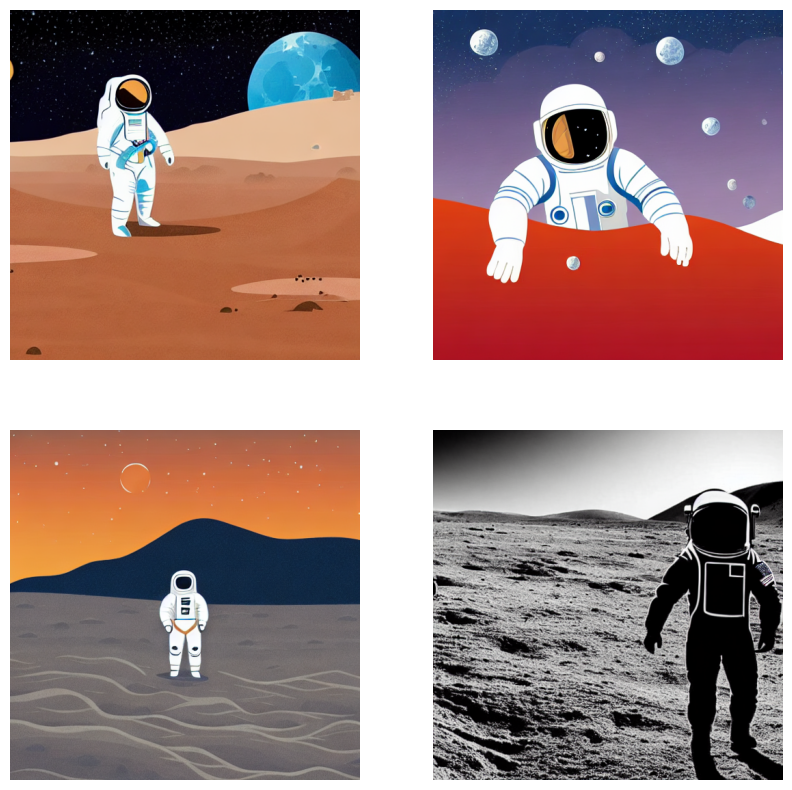

In [11]:
def generate_batch_images(prompt, negative_prompt, seed, num_images):
    generator = torch.Generator("cuda").manual_seed(seed)
    images = pipe(
        prompt=[prompt] * num_images,
        negative_prompt=[negative_prompt] * num_images,
        generator=generator,
        num_inference_steps=steps
    ).images
    return images

batch_images = generate_batch_images(prompt, negative_prompt, seed, 4)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for i, img in enumerate(batch_images):
    axs[i//2, i%2].imshow(img)
    axs[i//2, i%2].axis("off")
plt.show()


## **Load Scheduler**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

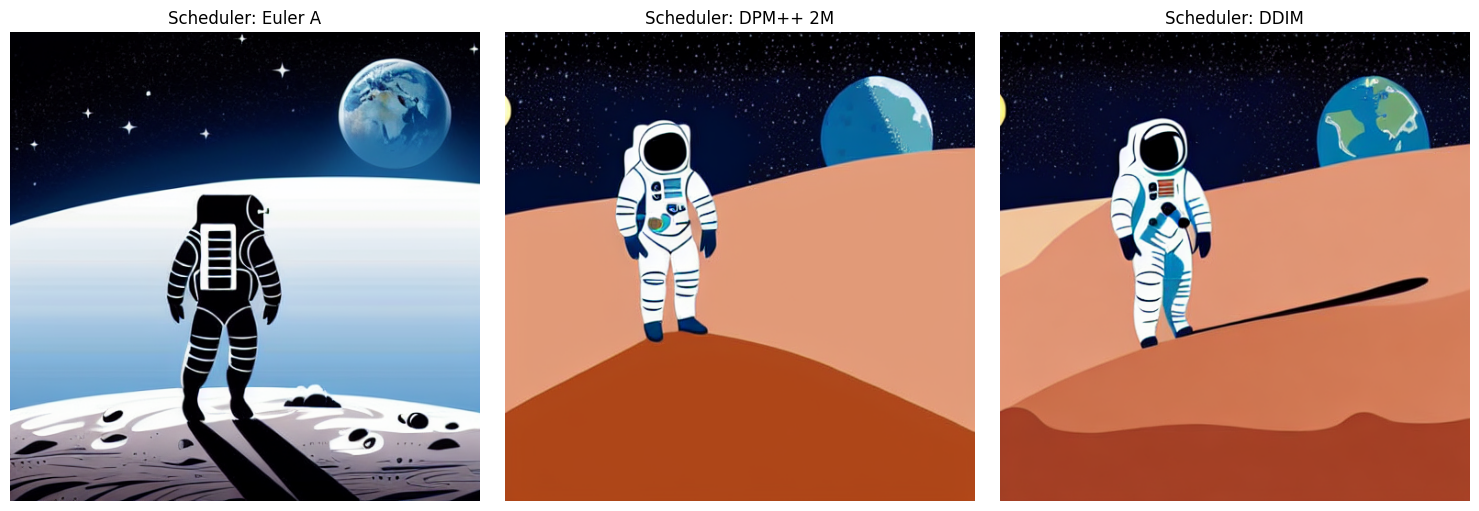

In [12]:
scheduler_configs = [
    (EulerAncestralDiscreteScheduler, "Euler A"),
    (DPMSolverMultistepScheduler, "DPM++ 2M"),
    (DDIMScheduler, "DDIM")
]

images = []

for scheduler_class, name in scheduler_configs:
    pipe.scheduler = scheduler_class.from_config(pipe.scheduler.config)

    generator = torch.Generator(device).manual_seed(seed)

    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        num_inference_steps=steps,
        guidance_scale=scales
    ).images[0]

    images.append((name, img))

plt.figure(figsize=(15, 5))

for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.title(f"Scheduler: {name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
    Hasil gambar cenderung memiliki kontras yang tinggi dan pencahayaan yang dramatis. Pada contoh, astronot terlihat sangat menonjol dengan efek overexposure atau pencahayaan terang yang kuat di permukaan bulan yang kontras dengan bayangan gelap.

*   **Gambar dengan "DPM++ Scheduler":**  
    Menghasilkan gambar bergaya vektor 2D, minimalis, flat design, dan ilustratif. Garis-garis objeknya sangat bersih, tajam, dengan pemisahan warna yang tegas (solid block colors) tanpa gradient yang rumit.

*   **Gambar dengan "DDIM Scheduler":**  
    Menghasilkan gambar yang paling realistis, natural, dan menyerupai foto asli dibandingkan dua lainnya. Tekstur permukaan bulan, detail baju astronot, dan gradasi warna monokromatik abu-abu terlihat sangat meyakinkan seperti dokumentasi aslinya.

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

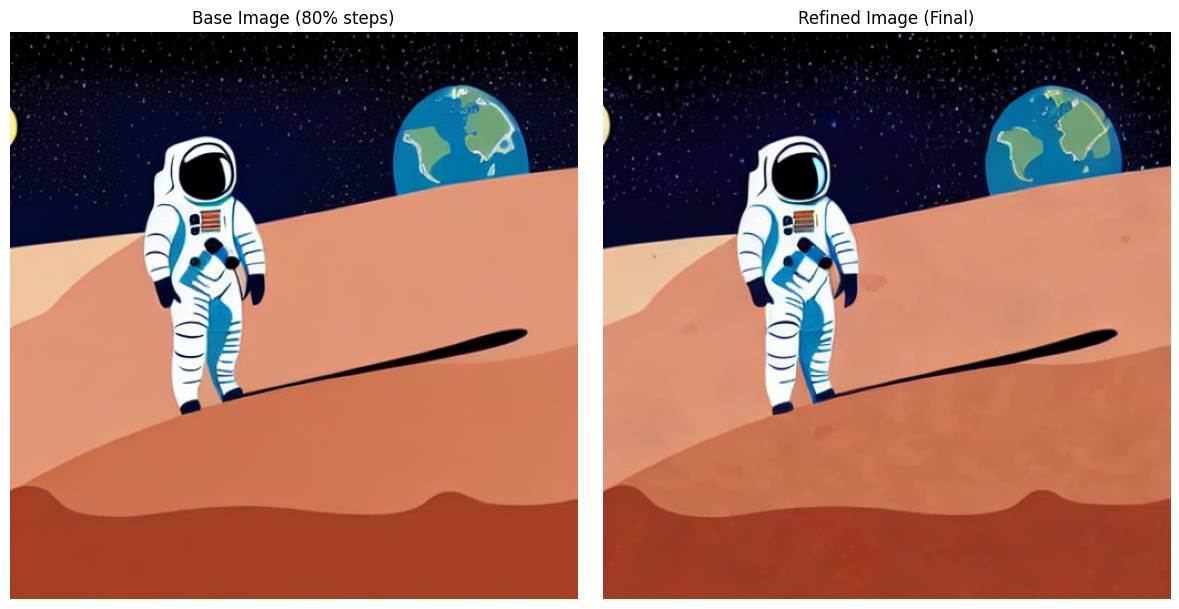

In [13]:
# Stage 2: Img2Img Refiner
from diffusers import StableDiffusionImg2ImgPipeline

refiner_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

# Base Generation (Base Step)
generator = torch.Generator("cuda").manual_seed(seed)
base_output = pipe(prompt=prompt,
                   negative_prompt=negative_prompt,
                   generator=generator,
                   num_inference_steps=steps,
                   guidance_scale=scales,
                   denoising_end = 0.8
                   ).images[0]


# Refiner Generation
refined_image = refiner_pipe(
                   prompt=prompt,
                   generator=generator,
                   negative_prompt=negative_prompt,
                  num_inference_steps=steps,
                   guidance_scale=scales,
                   image=base_output,
                   denoising_start=0.8,
                   strength=0.2
                   ).images[0]


# Membuat plot perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Menampilkan Base Output
axes[0].imshow(base_output)
axes[0].set_title("Base Image (80% steps)")
axes[0].axis("off")

# Menampilkan Refined Image
axes[1].imshow(refined_image)
axes[1].set_title("Refined Image (Final)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## **Inpainting**

### **Load Model Inpainting**

In [14]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=dtype,
    safety_checker=None
).to(device)

inpaint_pipe.enable_attention_slicing()

print("Inpainting model loaded!")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior 

Inpainting model loaded!


### **Manual Masking**

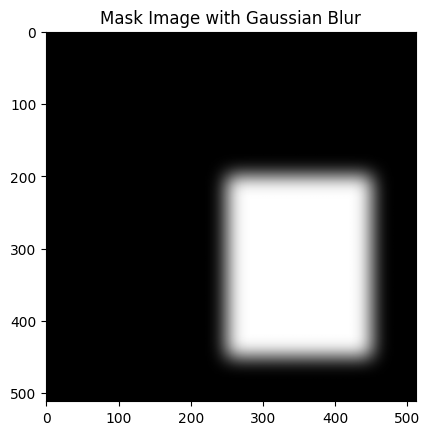

In [46]:
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt
import torch

init_image = simple_image.copy().convert("RGB").resize((512, 512))

# 1. Membuat Mask dengan Feathering (Soft Edges)
mask_image = Image.new("L", (512, 512), 0)
draw = ImageDraw.Draw(mask_image)
draw.rectangle([250, 200, 450, 450], fill=255)

# Berikan efek blur agar transisi objek baru dan latar belakang halus
mask_image = mask_image.filter(ImageFilter.GaussianBlur(radius=12))

# Menampilkan mask untuk pengecekan
plt.imshow(mask_image, cmap='gray')
plt.title("Mask Image with Gaussian Blur")
plt.show()



### **Generate**

  0%|          | 0/47 [00:00<?, ?it/s]

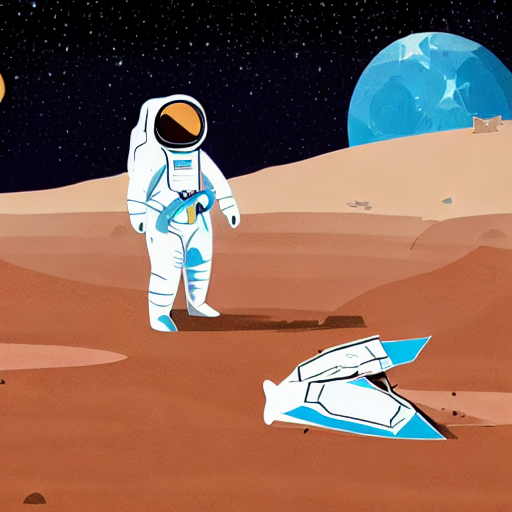

In [47]:
def inpaint_engine(image, mask, prompt, negative_prompt, seed, guidance_scale, num_inference_steps):
    generator = torch.Generator("cuda").manual_seed(seed)
    result = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        generator=generator,
        guidance_scale=guidance_scale,       # Diturunkan ke angka logis
        num_inference_steps=num_inference_steps,
        strength=0.95                         # Mengizinkan sedikit adaptasi dengan base image
    ).images[0]
    return result

inpaint_prompt = (
    "a clearly visible crashed satellite wreck inside the masked area, "

)

negative_prompt = (
    "empty ground, plain desert, only sand, no object, missing satellite, "
    "blurry, low quality, realistic photo, human, person, astronaut, robot, "
    "grass, water, trees, wooden board, flat panel only, text, watermark"
)


inpainted_image = inpaint_engine(init_image, mask_image, inpaint_prompt, negative_prompt, 9, scales, steps)
inpainted_image.save("inpainted_satellite_v4.png")
inpainted_image

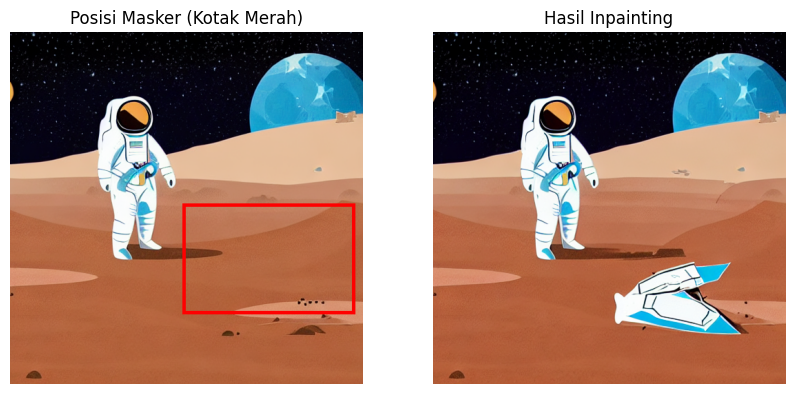

In [48]:
# Visualisasi untuk cek posisi masker terhadap gambar
temp_img = init_image.copy()
draw = ImageDraw.Draw(temp_img)
draw.rectangle([250, 250, 500, 410], outline="red", width=5)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(temp_img)
plt.title("Posisi Masker (Kotak Merah)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(inpainted_image)
plt.title("Hasil Inpainting")
plt.axis("off")
plt.show()

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

In [19]:
from transformers import pipeline as tf_pipeline
from PIL import Image, ImageDraw, ImageOps, ImageFilter
import matplotlib.pyplot as plt

# 1. Muat model segmentasi panoptic
segmenter = tf_pipeline("image-segmentation", model="facebook/detr-resnet-50-panoptic", device=0)



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/172M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/562 [00:00<?, ?it/s]

DetrForSegmentation LOAD REPORT from: facebook/detr-resnet-50-panoptic
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


### **Masking with Segmentation Model**

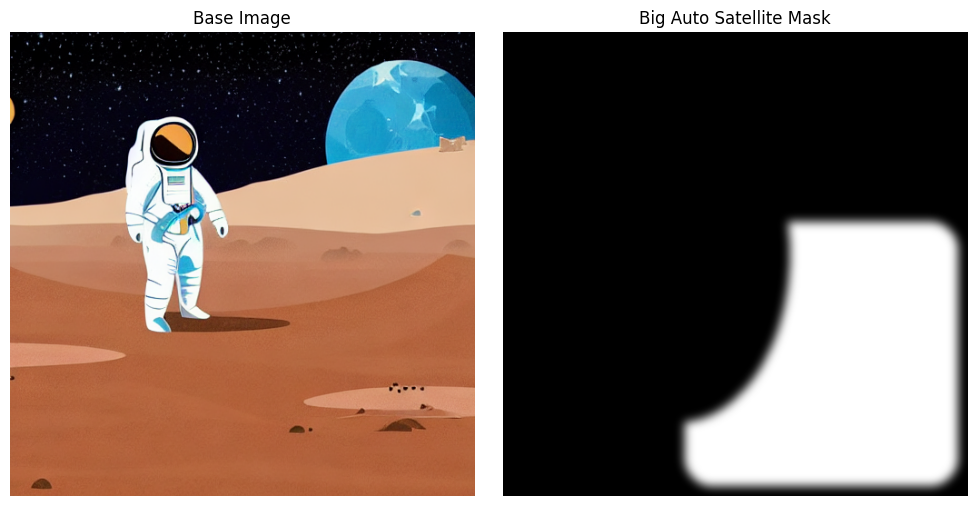

In [65]:
from PIL import Image, ImageDraw, ImageFilter, ImageChops
import matplotlib.pyplot as plt
import torch
import numpy as np

init_image = simple_image.copy().convert("RGB").resize((512, 512))

def create_auto_satellite_mask_big(image):
    """
    Automasking ukuran besar untuk membuat satelit lebih mungkin muncul.
    Area mask diperbesar di kanan bawah, tetapi area astronot tetap diproteksi.
    """

    image = image.convert("RGB").resize((512, 512))

    satellite_mask = Image.new("L", image.size, 0)
    draw_sat = ImageDraw.Draw(satellite_mask)

    # Area lebih besar dari sebelumnya
    # Sebelumnya kira-kira: [250, 250, 470, 420]
    # Ini diperbesar:
    draw_sat.rounded_rectangle(
        [200, 210, 500, 500],
        radius=30,
        fill=255
    )

    protect_mask = Image.new("L", image.size, 0)
    draw_protect = ImageDraw.Draw(protect_mask)

    # Area astronot diproteksi agar tidak ikut rusak
    draw_protect.ellipse(
        [70, 60, 315, 430],
        fill=255
    )

    final_mask = ImageChops.subtract(satellite_mask, protect_mask)

    # Feathering sedang
    final_mask = final_mask.filter(ImageFilter.GaussianBlur(radius=5))

    return final_mask


auto_mask_image = create_auto_satellite_mask_big(init_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Base Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(auto_mask_image, cmap="gray")
plt.title("Big Auto Satellite Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

### **Generate**

  0%|          | 0/80 [00:00<?, ?it/s]

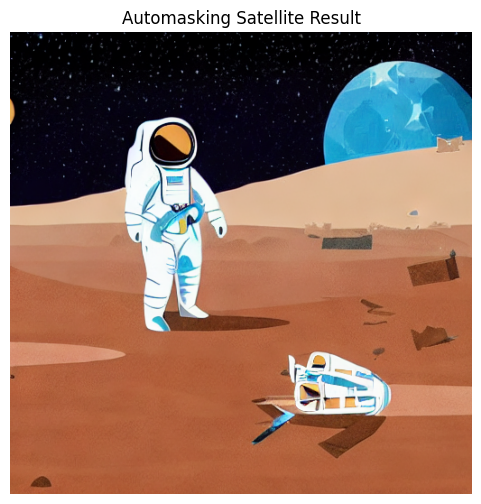

In [74]:
def inpaint_engine(
    image,
    mask,
    prompt,
    negative_prompt,
    seed,
    guidance_scale,
    num_inference_steps,
    strength
):
    generator = torch.Generator(device).manual_seed(seed)

    result = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        generator=generator,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        strength=strength
    ).images[0]

    return result


inpaint_prompt = (
    " broken satellite wreck, a clearly visible crashed satellite wreck inside the masked area, "
)

negative_prompt = (
    "empty ground, plain desert, only sand, no object, missing satellite, "
    "blurry, low quality, realistic photo, human, person, astronaut, robot, "
    "grass, water, trees, wooden board, flat panel only, text, watermark"
)

inpainted_image = inpaint_engine(
    image=init_image,
    mask=auto_mask_image,
    prompt=inpaint_prompt,
    negative_prompt=negative_prompt,
    seed=9,
    guidance_scale=14.0,
    num_inference_steps=80,
    strength=1.0
)

inpainted_image.save("automasking_satellite_result.png")

plt.figure(figsize=(6, 6))
plt.imshow(inpainted_image)
plt.title("Automasking Satellite Result")
plt.axis("off")
plt.show()

In [ ]:
temp_img = init_image.copy()
draw = ImageDraw.Draw(temp_img)

# Area kandidat satelit
draw.rounded_rectangle(
    [250, 250, 470, 420],
    radius=25,
    outline="red",
    width=5
)

# Area proteksi astronot
draw.ellipse(
    [90, 70, 300, 410],
    outline="blue",
    width=5
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(temp_img)
plt.title("Auto Mask Area: Merah = Satelit, Biru = Proteksi Astronot")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(inpainted_image)
plt.title("Hasil Inpainting Automasking")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Outpainting**

### **Prepare the Canvas**

In [22]:
from PIL import Image, ImageOps, ImageFilter

def prepare_outpainting(image, direction="right", pixels=256):
    width, height = image.size

    # 1. Tentukan ukuran kanvas baru secara dinamis
    if direction in ["right", "left"]:
        new_width = width + pixels
        new_height = height
    elif direction in ["top", "bottom"]:
        new_width = width
        new_height = height + pixels
    else:
        raise ValueError("Direction harus 'right', 'left', 'top', atau 'bottom'")

    # 2. Buat kanvas baru. Menggunakan gambar asli yang di-stretch + blur jauh lebih baik daripada hitam pekat
    # Ini memberikan estimasi warna latar belakang (misal warna merah tanah Mars) kepada AI
    new_image = image.resize((new_width, new_height)).filter(ImageFilter.GaussianBlur(radius=30))

    # Mask baru: default 255 (putih = area yang akan digambar oleh AI)
    mask = Image.new("L", (new_width, new_height), 255)

    # 3. Tempelkan gambar asli dan set mask hitam (0 = dilindungi) sesuai arahnya
    if direction == "right":
        new_image.paste(image, (0, 0))
        mask.paste(Image.new("L", (width, height), 0), (0, 0))

    elif direction == "left":
        new_image.paste(image, (pixels, 0))
        mask.paste(Image.new("L", (width, height), 0), (pixels, 0))

    elif direction == "top":
        new_image.paste(image, (0, pixels))
        mask.paste(Image.new("L", (width, height), 0), (0, pixels))

    elif direction == "bottom":
        new_image.paste(image, (0, 0))
        mask.paste(Image.new("L", (width, height), 0), (0, 0))

    # 4. TRIK AGAR TIDAK PATAH: Berikan sedikit blur pada border mask hitam-putih
    # Ini menciptakan transisi (feathering) agar gambar asli dan ekstensi baru menyatu alami
    mask = mask.filter(ImageFilter.GaussianBlur(radius=8))

    return new_image, mask



### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

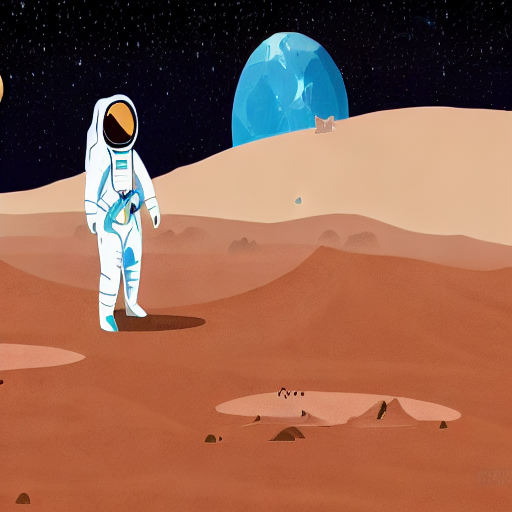

In [23]:
# --- PROSES EKSEKUSI PIPELINE ---

# Gunakan init_image (pastikan ukurannya standar, misal 512x512)
out_canvas, out_mask = prepare_outpainting(init_image, direction="right", pixels=256)

# PENTING: Jalankan inpainting dengan ukuran dimensi kanvas baru (jangan dipaksa ke 512x512 jika rasionya berubah)
# Stable Diffusion pipeline mendukung kelipatan 8 (768x512 sangat aman di GPU)
outpainted = inpaint_pipe(
    prompt="Mars landscape extension, red martian ground, craters, deep space, stars, photorealistic, 8k resolution",
    negative_prompt="blurry, bad anatomy, human, text, cropped, low quality",
    image=out_canvas,
    mask_image=out_mask,
    guidance_scale=10.0,
    num_inference_steps=50
).images[0]

outpainted.save("outpainted_mars_right.png")
outpainted

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

In [24]:
from PIL import Image, ImageFilter, ImageOps
import torch

def prepare_zoom_out_optimized(image, scale=1.5):
    w, h = image.size
    nw, nh = int(w * scale), int(h * scale)

    # 1. Trik Utama: Isi latar belakang dengan gambar asli yang di-stretch + blur pekat
    # Ini memberikan kisi-kisi warna (color cues) tanah dan langit ke model AI
    canvas = image.resize((nw, nh)).filter(ImageFilter.GaussianBlur(radius=40))

    # Tempatkan gambar asli di tengah-tengah kanvas baru
    offset = ((nw - w) // 2, (nh - h) // 2)
    canvas.paste(image, offset)

    # 2. Buat Mask (255 = Putih untuk area baru yang digambar AI)
    mask = Image.new('L', (nw, nh), 255)
    # Proteksi gambar asli di tengah dengan mask hitam (0)
    mask.paste(Image.new('L', (w, h), 0), offset)

    # 3. Berikan efek blur pada mask agar transisi sambungannya halus (Feathering)
    mask = mask.filter(ImageFilter.GaussianBlur(radius=12))

    # Kembalikan ke ukuran 512x512 secara proporsional (bebas distorsi)
    return canvas.resize((512, 512)), mask.resize((512, 512))



### **Generate**


  0%|          | 0/30 [00:00<?, ?it/s]

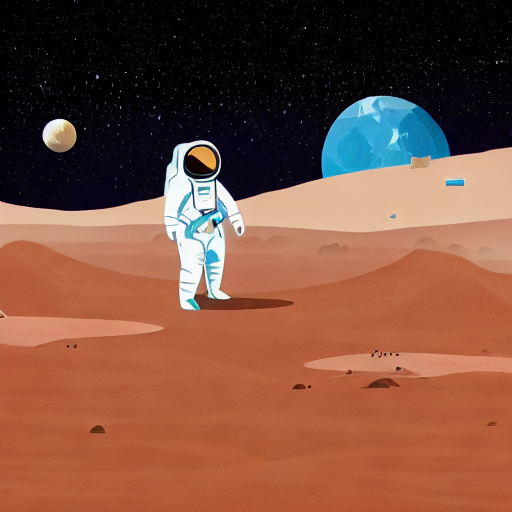

In [25]:
# --- EKSEKUSI ZOOM OUT ---

# Siapkan kanvas dan mask dengan fungsi optimasi baru
zoom_canvas, zoom_mask = prepare_zoom_out_optimized(init_image, scale=1.4) # Skala 1.4 - 1.5 adalah rentang paling aman

# Jalankan inpaint pipeline
zoomed_image = inpaint_pipe(
    prompt="Wide angle cinematic shot of an astronaut on the red rocky Mars surface, hills and craters in distance, small Earth visible in the deep space background, photorealistic, 8k resolution",
    negative_prompt="blurry, low quality, deformed, duplicate, cropped, bad anatomy, text, signature",
    image=zoom_canvas,
    mask_image=zoom_mask,
    guidance_scale=11.0,  # Berikan ruang kontrol prompt yang kuat
    num_inference_steps=30 # Naikkan steps agar detail ekstensinya matang
).images[0]

zoomed_image.save("mars_zoom_out_perfect.png")
zoomed_image